In [20]:
import tensorflow as tf

In [21]:
mnist = tf.keras.datasets.mnist

In [22]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
x_train.shape

(60000, 28, 28)

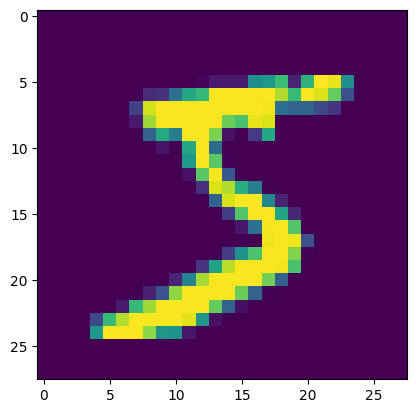

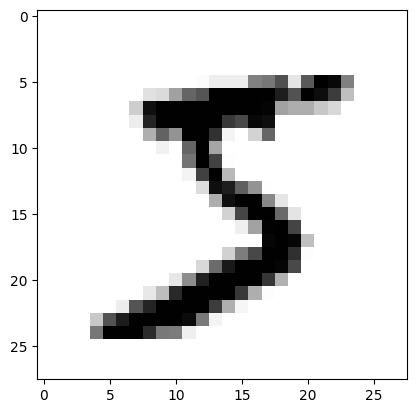

In [24]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
plt.imshow(x_train[0], cmap = plt.cm.binary) #black & white (grayscale) image

In [25]:
print (x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

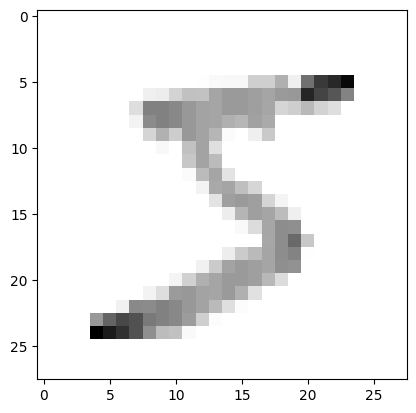

In [26]:
 #normalize
x_train = tf.keras.utils.normalize(x_train, axis= 1)
x_test = tf.keras.utils.normalize(x_test, axis= 1)
plt.imshow(x_train[0], cmap=plt.cm.binary)


In [27]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [28]:
print(y_train[0])

5


In [29]:
import numpy as np
IMG_SIZE = 28
x_trainr = np.array(x_train).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
x_testr =np.array(x_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print("traing sample dimention" , x_trainr.shape)
print("testing sample dimention" , x_testr.shape)



traing sample dimention (60000, 28, 28, 1)
testing sample dimention (10000, 28, 28, 1)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Dropout , Activation , Flatten, Conv2D, MaxPooling2D

In [31]:
from matplotlib.cbook import flatten
model = Sequential()

#first conv
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))


#2nd conv
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

#3rd conv
model.add(Conv2D(64, (3,3), input_shape = x_trainr.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

#fully connected layer
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

#fully connected layer
model.add(Dense(32))
model.add(Activation("relu"))

#last  layer
model.add(Dense(10))
model.add(Activation('softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,066 (316.66 KB)

 Trainable params: 81,066 (316.66 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
print("total traing samples = ", len(x_trainr))

total traing samples =  60000


In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.fit(x_trainr,y_train,epochs=5, validation_split= 0.3)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.8934 - loss: 0.3431 - val_accuracy: 0.9641 - val_loss: 0.1177
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 95s 71ms/step - accuracy: 0.9652 - loss: 0.1129 - val_accuracy: 0.9673 - val_loss: 0.1052
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 132s 64ms/step - accuracy: 0.9752 - loss: 0.0800 - val_accuracy: 0.9746 - val_loss: 0.0876
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 136s 60ms/step - accuracy: 0.9800 - loss: 0.0637 - val_accuracy: 0.9778 - val_loss: 0.0719
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9781 - val_loss: 0.0717


In [36]:
test_loss, test_acc = model.evaluate(x_testr, y_test)
print("test loss on 10,000 test sample", test_loss)
print ("validation accuracy on 10,000 test samples", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9780 - loss: 0.0690
test loss on 10,000 test sample 0.06902702152729034
validation accuracy on 10,000 test samples 0.9779999852180481


In [37]:
predicions = model.predict(x_testr)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


In [38]:
print (predicions)

[[6.3934590e-07 2.5035629e-06 1.4893973e-04 ... 9.9978542e-01
  1.6714807e-06 1.9449102e-05]
 [8.0409518e-07 2.8698420e-05 9.9996489e-01 ... 2.1408670e-07
  1.0888235e-07 8.1614195e-07]
 [6.1607204e-07 9.9992853e-01 1.1805459e-05 ... 4.9692908e-06
  1.3735073e-06 1.3923243e-06]
 ...
 [1.7146670e-08 1.5005395e-06 3.9674810e-09 ... 1.1939567e-08
  6.7872657e-05 9.7901875e-06]
 [1.4706330e-06 6.8893726e-09 4.5385942e-10 ... 7.9444256e-09
  9.0649917e-07 1.2277702e-06]
 [2.4022415e-06 1.3515417e-08 1.3731307e-06 ... 6.4037733e-11
  3.9719816e-06 5.8513308e-07]]


In [39]:
print (np.argmax(predicions[0]))

7


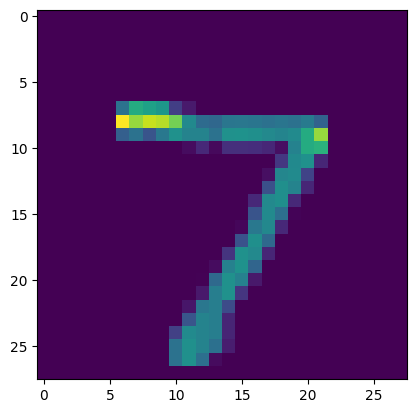

In [40]:
plt.imshow(x_test[0])

In [41]:
import cv2

In [42]:
import matplotlib.pyplot as plt

In [43]:
img = cv2.imread('/Zero.jpg')

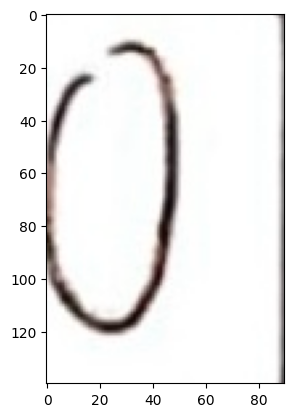

In [44]:
plt.imshow(img)

In [45]:
img.shape

(140, 90, 3)

In [46]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [47]:
gray.shape

(140, 90)

In [48]:
resized = cv2.resize(gray, (28,28),interpolation= cv2.INTER_AREA)

In [49]:
resized.shape

(28, 28)

In [50]:
import tensorflow as tf

In [51]:
newimg = tf.keras.utils.normalize(resized, axis = 1)

In [52]:
newimg = np.array(newimg).reshape(-1, IMG_SIZE,IMG_SIZE,1)

In [60]:
newimg.shape

(1, 28, 28, 1)

In [65]:
predicions = model.predict(newimg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [66]:
print (np.argmax(predicions))

0
